### Install dependencies

In [1]:
%pip install -U langchain langgraph langchain-ollama langgraph-checkpoint-sqlite langsmith requests

Looking in indexes: https://packagefeedproxy.microsoft.io/pypi/simple/
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.15
    Uninstalling langchain-1.3.15:
      Successfully uninstalled langchain-1.3.15
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Enable LangSmith tracing

In [2]:
import getpass
import os

TRACING = True
LANGSMITH_PROJECT = "sql-agent"

if TRACING:
    os.environ["LANGSMITH_TRACING"] = "true"
    os.environ["LANGSMITH_PROJECT"] = LANGSMITH_PROJECT
    if not os.environ.get("LANGSMITH_API_KEY"):
        os.environ["LANGSMITH_API_KEY"] = getpass.getpass("LANGSMITH_API_KEY: ")
else:
    os.environ.pop("LANGSMITH_TRACING", None)

print(f"tracing: {os.environ.get('LANGSMITH_TRACING', 'off')}")

tracing: true


### Select a model

In [60]:
import os

from langchain_ollama import ChatOllama

PROVIDER = "ollama"
MODEL = "qwen2.5:14b"
OLLAMA_BASE_URL = os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434")

model = ChatOllama(
    model=MODEL,
    base_url=OLLAMA_BASE_URL,
    temperature=0,
    num_ctx=16384,
)

print(model.invoke("Reply with the single word: ready").text)
print(f"model ready -> {PROVIDER}:{MODEL}")

ready
model ready -> ollama:qwen2.5:14b


### Download the Chinook database

In [68]:
import shutil
from pathlib import Path

import requests

DATA_DIR = (Path.cwd() / "data").resolve()
DATA_DIR.mkdir(parents=True, exist_ok=True)

SEED_DB_PATH = DATA_DIR / "Chinook.db"
DB_PATH = DATA_DIR / "Chinook_demo.db"
DB_URL = "https://storage.googleapis.com/benchmarks-artifacts/chinook/Chinook.db"

if SEED_DB_PATH.exists():
    print(f"{SEED_DB_PATH.name} already present ({SEED_DB_PATH.stat().st_size:,} bytes)")
else:
    response = requests.get(DB_URL, timeout=60)
    response.raise_for_status()
    SEED_DB_PATH.write_bytes(response.content)
    print(f"downloaded {SEED_DB_PATH.name} ({SEED_DB_PATH.stat().st_size:,} bytes)")


def reset_demo_db() -> Path:
    shutil.copyfile(SEED_DB_PATH, DB_PATH)
    return DB_PATH


if not DB_PATH.exists():
    reset_demo_db()

print(f"writable copy -> {DB_PATH.relative_to(Path.cwd())} ({DB_PATH.stat().st_size:,} bytes)")

Chinook.db already present (913,408 bytes)
writable copy -> data\Chinook_demo.db (913,408 bytes)


### Read-only connection and query guards

In [6]:
import re
import sqlite3
from contextlib import closing

MAX_ROWS = 50
MAX_CHARS = 4_000

READ_ONLY = re.compile(r"^(?:select|with|explain)\b", re.IGNORECASE)
WRITE = re.compile(r"^(?:insert|update|delete|create|alter|drop)\b", re.IGNORECASE)
FORBIDDEN = re.compile(r"^(?:attach|detach|pragma|vacuum)\b", re.IGNORECASE)


def connect() -> sqlite3.Connection:
    return sqlite3.connect(f"{DB_PATH.as_uri()}?mode=ro", uri=True)


def connect_rw() -> sqlite3.Connection:
    return sqlite3.connect(DB_PATH)


def single_statement(query: str) -> str:
    statement = query.strip().rstrip(";").strip()
    if ";" in statement:
        raise ValueError("only one statement per query is allowed")
    if FORBIDDEN.match(statement):
        raise ValueError("ATTACH, DETACH, PRAGMA and VACUUM are not allowed")
    return statement


def check_read_only(query: str) -> str:
    statement = single_statement(query)
    if not READ_ONLY.match(statement):
        raise ValueError("only SELECT, WITH or EXPLAIN queries are allowed")
    return statement


def check_write(query: str) -> str:
    statement = single_statement(query)
    if not WRITE.match(statement):
        raise ValueError("only INSERT, UPDATE, DELETE, CREATE, ALTER or DROP are allowed")
    return statement


def truncate(text: str) -> str:
    return text if len(text) <= MAX_CHARS else f"{text[:MAX_CHARS]}\n... [truncated]"


with closing(connect()) as con:
    con.execute("SELECT 1")
print(f"read-only connection OK -> {DB_PATH.name}")

try:
    with closing(connect()) as con:
        con.execute("CREATE TABLE should_not_exist (x INTEGER)")
except sqlite3.OperationalError as exc:
    print(f"read handle still blocks writes: {exc}")
else:
    raise AssertionError("the read handle must never be writable")

with closing(connect_rw()) as con:
    con.execute("CREATE TABLE IF NOT EXISTS demo_scratch (x INTEGER)")
    con.execute("DROP TABLE demo_scratch")
    con.commit()
print("read-write connection OK")

read-only connection OK -> Chinook_demo.db
read handle still blocks writes: attempt to write a readonly database
read-write connection OK


In [10]:
with closing(connect()) as con:
    cursor = con.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = [row[0] for row in cursor.fetchall() if not row[0].startswith("sqlite_")]
    cursor.execute("SELECT * FROM Artist LIMIT 5;")
    sample = cursor.fetchall()

print("Dialect: sqlite")
print(f"Available tables: {tables}")
print(f"Sample output: {sample}")

Dialect: sqlite
Available tables: ['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']
Sample output: [(1, 'AC/DC'), (2, 'Accept'), (3, 'Aerosmith'), (4, 'Alanis Morissette'), (5, 'Alice In Chains')]


### Define the database tools

In [11]:
from langchain.tools import tool


@tool
def sql_db_list_tables() -> str:
    """Input is an empty string, output is a comma-separated list of tables in the database."""
    with closing(connect()) as con:
        cursor = con.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        names = [row[0] for row in cursor.fetchall() if not row[0].startswith("sqlite_")]
    return ", ".join(names)


@tool
def sql_db_schema(table_names: str) -> str:
    """Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables.
    Be sure that the tables actually exist by calling sql_db_list_tables first!
    Example Input: table1, table2, table3"""
    with closing(connect()) as con:
        cursor = con.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        valid = {row[0] for row in cursor.fetchall() if not row[0].startswith("sqlite_")}

        results = []
        for raw in table_names.split(","):
            table = raw.strip()
            if table not in valid:
                results.append(f"Error: table {table!r} not found in database")
                continue

            cursor.execute(
                "SELECT sql FROM sqlite_master WHERE type='table' AND name=?;", (table,)
            )
            schema_row = cursor.fetchone()
            if not schema_row:
                continue
            results.append(schema_row[0])

            cursor.execute(f'SELECT * FROM "{table}" LIMIT 3;')
            rows = cursor.fetchall()
            if rows:
                columns = [d[0] for d in cursor.description]
                body = "\n".join("\t".join(str(value) for value in row) for row in rows)
                results.append(
                    f"/*\n3 rows from {table} table:\n"
                    + "\t".join(columns)
                    + f"\n{body}\n*/"
                )

    return truncate("\n\n".join(results))

In [8]:
@tool
def sql_db_query(query: str) -> str:
    """Input to this tool is a detailed and correct SQL query, output is a result from the database.
    Only read queries are permitted: SELECT, WITH or EXPLAIN, one statement at a time.
    If the query is not correct, an error message will be returned.
    If an error is returned, rewrite the query, check the query, and try again.
    If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields."""
    try:
        statement = check_read_only(query)
    except ValueError as exc:
        return f"Error: {exc}"

    try:
        with closing(connect()) as con:
            cursor = con.cursor()
            cursor.execute(statement)
            rows = cursor.fetchmany(MAX_ROWS)
            has_more = cursor.fetchone() is not None
    except sqlite3.Error as exc:
        return f"Error: {exc}"

    note = f"\n... more than {MAX_ROWS} rows; add LIMIT or aggregate." if has_more else ""
    return truncate(str(rows) + note)


@tool
def sql_db_write(query: str) -> str:
    """Input to this tool is a single INSERT, UPDATE, DELETE, CREATE, ALTER or DROP statement.
    Output is the number of rows affected, or an error message.
    Use this ONLY when the user has explicitly asked you to change the database.
    Always confirm which rows you are about to touch with sql_db_query first, and
    always include a WHERE clause on UPDATE and DELETE."""
    try:
        statement = check_write(query)
    except ValueError as exc:
        return f"Error: {exc}"

    try:
        with closing(connect_rw()) as con:
            cursor = con.cursor()
            cursor.execute(statement)
            con.commit()
            affected = cursor.rowcount
    except sqlite3.Error as exc:
        return f"Error: {exc}"

    return f"OK, {max(affected, 0)} row(s) affected"


@tool
def sql_db_query_checker(query: str) -> str:
    """Use this tool to double check if your query is correct before executing it.
    Always use this tool before executing a query with sql_db_query!"""
    trigger_prompt = """{query}
Double check the sqlite query above for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Using BETWEEN for exclusive ranges
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Casting to the correct data type
- Using the proper columns for joins

If there are any of the above mistakes, rewrite the query. If there are no mistakes, just reproduce the original query.

Output the final SQL query only.

SQL Query: """.format(query=query)

    response = model.invoke(trigger_prompt)
    return response.text.strip()


tools = [sql_db_list_tables, sql_db_schema, sql_db_query, sql_db_write, sql_db_query_checker]

for entry in tools:
    print(f"{entry.name}: {entry.description}\n")

sql_db_list_tables: Input is an empty string, output is a comma-separated list of tables in the database.

sql_db_schema: Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables.
    Be sure that the tables actually exist by calling sql_db_list_tables first!
    Example Input: table1, table2, table3

sql_db_query: Input to this tool is a detailed and correct SQL query, output is a result from the database.
    Only read queries are permitted: SELECT, WITH or EXPLAIN, one statement at a time.
    If the query is not correct, an error message will be returned.
    If an error is returned, rewrite the query, check the query, and try again.
    If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.

sql_db_write: Input to this tool is a single INSERT, UPDATE, DELETE, CREATE, ALTER or DROP statement.
    Output is the number of rows affected, or an error message.
    Use

In [15]:
print(sql_db_list_tables.invoke({}))
print()
print(sql_db_schema.invoke({"table_names": "Genre, Nonexistent"}))
print()

probes = [
    "SELECT Name FROM Genre LIMIT 3",
    "DROP TABLE Album",
    "SELECT 1; DROP TABLE Album",
    "UPDATE Track SET UnitPrice = 0",
    "SELECT nope FROM Genre",
]

for probe in probes:
    print(f"{probe!r}\n  -> {sql_db_query.invoke({'query': probe})}\n")

write_probes = [
    "UPDATE Genre SET Name = 'Rock Music' WHERE GenreId = 1",
    "INSERT INTO Genre (Name) VALUES ('Synthwave')",
    "SELECT Name FROM Genre LIMIT 3",
    "DELETE FROM Genre WHERE GenreId = 1; DROP TABLE Album",
]

for probe in write_probes:
    print(f"{probe!r}\n  -> {sql_db_write.invoke({'query': probe})}\n")

print(sql_db_query.invoke({"query": "SELECT Name FROM Genre WHERE Name IN ('Rock Music', 'Synthwave')"}))

reset_demo_db()
print(f"restored {DB_PATH.name}")

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track

CREATE TABLE [Genre]
(
    [GenreId] INTEGER  NOT NULL,
    [Name] NVARCHAR(120),
    CONSTRAINT [PK_Genre] PRIMARY KEY  ([GenreId])
)

/*
3 rows from Genre table:
GenreId	Name
1	Rock
2	Jazz
3	Metal
*/

Error: table 'Nonexistent' not found in database

'SELECT Name FROM Genre LIMIT 3'
  -> [('Rock',), ('Jazz',), ('Metal',)]

'DROP TABLE Album'
  -> Error: only SELECT, WITH or EXPLAIN queries are allowed

'SELECT 1; DROP TABLE Album'
  -> Error: only one statement per query is allowed

'UPDATE Track SET UnitPrice = 0'
  -> Error: only SELECT, WITH or EXPLAIN queries are allowed

'SELECT nope FROM Genre'
  -> Error: no such column: nope

"UPDATE Genre SET Name = 'Rock Music' WHERE GenreId = 1"
  -> OK, 1 row(s) affected

"INSERT INTO Genre (Name) VALUES ('Synthwave')"
  -> OK, 1 row(s) affected

'SELECT Name FROM Genre LIMIT 3'
  -> Error: only INSERT, UPDATE, DELETE, CREATE, ALTER 

### Create the agent

In [66]:
from langchain.agents import create_agent

system_prompt = """
CRITICAL LANGUAGE RULE: You must write every word of every response in English.
This applies to your reasoning, your explanations and your final answer. Never
switch to another language for any reason.

You are an agent designed to interact with a SQL database.

Given an input question, create a syntactically correct {dialect} query to run,
then look at the results of the query and return the answer. Unless the user
specifies a specific number of examples they wish to obtain, always limit your
query to at most {top_k} results.

You can order the results by a relevant column to return the most interesting
examples in the database. Never query for all the columns from a specific table,
only ask for the relevant columns given the question.

Before you call sql_db_query you MUST call sql_db_query_checker on the exact query
you intend to run. Never call sql_db_query without checking the query first. If you
get an error while executing a query, rewrite the query and try again.

Read the database with sql_db_query. Only if the user has explicitly asked you to
change the data may you use sql_db_write, one statement at a time. Never write to
the database on your own initiative, always run a SELECT first to confirm exactly
which rows you are about to affect, and always put a WHERE clause on UPDATE and
DELETE.

To start you should ALWAYS look at the tables in the database to see what you
can query. Do NOT skip this step.

Then you should query the schema of the most relevant tables.

Reminder: respond only in English.
""".format(dialect="sqlite", top_k=5)

agent = create_agent(model, tools, system_prompt=system_prompt)
print("agent ready")

agent ready


### Run the agent

In [ ]:
ENGLISH_REMINDER = (
    "Write your entire reply in English, starting from the very first word. "
    "Do not use Thai, Chinese or any other language."
)


def stream_agent(runnable, payload, config=None):
    stream = runnable.stream_events(payload, config, version="v3")

    channels = [name for name in ("messages", "tool_calls") if name in stream.extensions]

    for kind, item in stream.interleave(*channels):
        if kind == "messages":
            for token in item.text:
                print(token, end="", flush=True)
        elif kind == "tool_calls":
            print(f"\n[tool] {item.tool_name}({item.input})")
            for delta in item.output_deltas:
                print(delta, end="", flush=True)
            print(f"\n[result] {item.output}\n")

    if stream.interrupted:
        print("\n--- INTERRUPTED, awaiting approval ---")
        value = stream.interrupts[0].value
        requests = value["action_requests"] if isinstance(value, dict) else value
        for request in requests:
            print(request.get("description", request))

    return stream


def user_turn(question: str) -> dict:
    return {"messages": [{"role": "user", "content": f"{question}\n\n{ENGLISH_REMINDER}"}]}


def ask(question: str, runnable=None, config=None):
    runnable = runnable if runnable is not None else agent
    print(f"Q: {question}\n")
    return stream_agent(runnable, user_turn(question), config)

#### What one `ask(...)` call actually does

The model never touches the database. It only ever emits **tool calls**, reads the
**tool results** that get appended to the conversation, and decides what to ask for
next. The loop ends when it finally replies with no tool call.

```mermaid
sequenceDiagram
    autonumber
    participant Cell as Notebook cell
    participant Ask as ask
    participant Render as stream_agent
    participant Graph as agent graph
    participant LLM as qwen2.5:14b on Ollama
    participant Tools as SQL tools
    participant DB as Chinook_demo.db

    Cell->>Ask: Which genre on average has the longest tracks?
    Ask->>Render: messages payload
    Render->>Graph: stream_events

    Note over Graph,LLM: turn 1 - discover
    Graph->>LLM: system prompt + question + 5 tool schemas
    LLM-->>Graph: plan text, then call sql_db_list_tables
    Graph->>Tools: sql_db_list_tables
    Tools->>DB: SELECT name FROM sqlite_master
    DB-->>Tools: table names
    Tools-->>Graph: Album, Artist, ... Genre, ... Track

    Note over Graph,LLM: turn 2 - inspect, with one bad-arg retry
    Graph->>LLM: conversation so far
    LLM-->>Graph: sql_db_schema with wrong key tables
    Graph-->>LLM: schema validation fails, result None
    LLM-->>Graph: retry sql_db_schema with table_names
    Graph->>Tools: sql_db_schema Track, Genre
    Tools->>DB: DDL + 3 sample rows each
    DB-->>Tools: Milliseconds, GenreId, Name
    Tools-->>Graph: schema text

    Note over Graph,LLM: turn 3 - synthesise SQL
    Graph->>LLM: conversation so far
    LLM-->>Graph: writes JOIN + AVG + GROUP BY + ORDER BY + LIMIT

    Note over Graph,LLM: turn 4 - self-check
    LLM-->>Graph: call sql_db_query_checker
    Graph->>Tools: sql_db_query_checker
    Tools->>LLM: second LLM pass over the SQL
    LLM-->>Tools: query is correct, unchanged
    Tools-->>Graph: verified SQL

    Note over Graph,LLM: turn 5 - execute
    LLM-->>Graph: call sql_db_query
    Graph->>Tools: sql_db_query
    Tools->>Tools: check_read_only passes
    Tools->>DB: SELECT over read-only handle
    DB-->>Tools: Sci Fi & Fantasy, 2911783.04
    Tools-->>Graph: rows

    Note over Graph,LLM: turn 6 - answer
    LLM-->>Graph: final answer, no tool calls
    Graph-->>Render: run complete
    Render-->>Cell: stream object
    Cell->>Cell: final_state = stream.output
```

##### The same run, as it really happened

**1. Discover the tables.** The model cannot guess schema, so the system prompt forces
this step first.

```text
[tool] sql_db_list_tables({})
[result] Album, Artist, Customer, Employee, Genre, Invoice,
         InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
```

**2. Inspect the two relevant tables — including a self-correction.** The first call used
the wrong argument name, so schema validation rejected it and the tool never ran:

```text
[tool] sql_db_schema({'tables': 'Track, Genre'})
[result] None
```

The model read that failure and retried with the correct key. This is the loop's error
recovery working — nothing crashed, the bad result just became context:

```text
[tool] sql_db_schema({'table_names': 'Track, Genre'})
[result] CREATE TABLE [Track] ( ... [GenreId] INTEGER, [Milliseconds] INTEGER NOT NULL ... )
         /* 3 rows from Track table: ... 343719 ... */
         CREATE TABLE [Genre] ( [GenreId] INTEGER NOT NULL, [Name] NVARCHAR(120) ... )
         /* 3 rows from Genre table: 1 Rock / 2 Jazz / 3 Metal */
```

That output is what makes the next step possible: it reveals `Milliseconds` lives on
`Track`, that `GenreId` is the join key, and that the genre label column is `Name`.

**3. Synthesise the SQL.** Only now can the model write a correct query, because every
identifier in it came from step 2:

```sql
SELECT g.Name AS Genre, AVG(t.Milliseconds) AS AverageLength
FROM Track t
JOIN Genre g ON t.GenreId = g.GenreId
GROUP BY g.Name
ORDER BY AverageLength DESC
LIMIT 1;
```

**4. Check the query before running it.** `sql_db_query_checker` is unusual — it is a tool
whose implementation is *another LLM call*, so the model reviews its own SQL:

```text
[tool] sql_db_query_checker({'query': 'SELECT g.Name AS Genre, AVG(t.Milliseconds) ...'})
[result] The provided SQL query does not contain any of the mentioned common
         mistakes. ... Here is the original query: ...
```

**5. Execute.** `check_read_only` accepts it, the read-only handle runs it:

```text
[tool] sql_db_query({'query': 'SELECT g.Name AS Genre, AVG(t.Milliseconds) ... LIMIT 1;'})
[result] [('Sci Fi & Fantasy', 2911783.0384615385)]
```

**6. Answer.** The model emits text with no tool call, so `should_continue` ends the loop.

##### Two things this trace exposes

The model **second-guessed a correct answer**. Because `Sci Fi & Fantasy` did not look like
a music genre, it ran an unbounded follow-up to see every genre, found `Comedy`,
`TV Shows` and `Drama` sitting above the music entries, and hedged by also offering
`Rock`. The data is right — Chinook contains video content — but note that the plain
`agent` let that second, `LIMIT`-less query run unchallenged. The `gated_agent` later in
this notebook is exactly the countermeasure: `is_unbounded` would have paused it.

Tool results are **appended to the conversation**, so every schema dump and every result
row stays in context. That is why `num_ctx=16384` matters, and why `truncate()` caps tool
output at `MAX_CHARS` — a wide table could otherwise evict the original question.

`stream_agent` prints tokens as they arrive, so the run is visible while it happens.
`stream.output` is the *final state* — a dict whose `messages` list holds the entire
exchange, including every tool call and result. The printing is the live view;
`final_state` is the structured record you can inspect afterwards.


In [65]:
stream = ask("Which genre on average has the longest tracks?")
final_state = stream.output

Q: Which genre on average has the longest tracks?

To determine which genre has the longest tracks on average, I need to look at the relevant tables in the database. I will start by listing the tables in the database.


[tool] sql_db_list_tables({})

[result] content='Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track' name='sql_db_list_tables' tool_call_id='9734253d-da28-4949-bdb6-58680538c060'

I have listed the tables in the database. The relevant tables for this question are 'Track' and 'Genre'. I will now query the schema of these tables to understand their structure.


[tool] sql_db_schema({'table_names': 'Track, Genre'})

[result] content='CREATE TABLE [Track]\n(\n    [TrackId] INTEGER  NOT NULL,\n    [Name] NVARCHAR(200)  NOT NULL,\n    [AlbumId] INTEGER,\n    [MediaTypeId] INTEGER  NOT NULL,\n    [GenreId] INTEGER,\n    [Composer] NVARCHAR(220),\n    [Milliseconds] INTEGER  NOT NULL,\n    [Bytes] INTEGER,\n    [UnitPrice] 

### Pause for human review before running a query

In [30]:
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

review_agent = create_agent(
    model,
    tools,
    system_prompt=system_prompt,
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={"sql_db_query": True, "sql_db_write": True},
            description_prefix="Tool execution pending approval",
        ),
    ],
    checkpointer=InMemorySaver(),
)

config = {"configurable": {"thread_id": "1"}}
print("review agent ready")

review agent ready


In [49]:
stream = ask(
    "Which genre on average has the longest tracks?",
    runnable=review_agent,
    config=config,
)

Q: Which genre on average has the longest tracks?

คณะกรรมการทำงานจะเริ่มต้นด้วยการดูตารางในฐานข้อมูลก่อน ดังนั้นผมจะเรียกใช้ฟังก์ชัน `sql_db_list_tables` เพื่อดูว่ามีตารางอะไรบ้างในฐานข้อมูล


[tool] sql_db_list_tables({})

[result] content='Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track' name='sql_db_list_tables' tool_call_id='cfb579cb-0e4b-4573-ac55-5556da750302'

 Woodward, now that I know the tables in the database, I need to find out which columns are relevant to the question. The question is about the average track length by genre, so I should look at the schema for the `Track` and `Genre` tables.


[tool] sql_db_schema({'table_names': 'Track, Genre'})

[result] content='CREATE TABLE [Track]\n(\n    [TrackId] INTEGER  NOT NULL,\n    [Name] NVARCHAR(200)  NOT NULL,\n    [AlbumId] INTEGER,\n    [MediaTypeId] INTEGER  NOT NULL,\n    [GenreId] INTEGER,\n    [Composer] NVARCHAR(220),\n    [Milliseconds] INTEGER  NOT NULL,\n  

In [50]:
from langgraph.types import Command

decision = {"type": "approve"}

stream = stream_agent(
    review_agent,
    Command(resume={"decisions": [decision]}),
    config,
)


[tool] sql_db_query({'query': 'SELECT t.GenreId, g.Name AS GenreName, AVG(t.Milliseconds) AS AvgLength FROM Track t JOIN Genre g ON t.GenreId = g.GenreId GROUP BY t.GenreId, g.Name ORDER BY AvgLength DESC LIMIT 5'})

[result] content="[(20, 'Sci Fi & Fantasy', 2911783.0384615385), (18, 'Science Fiction', 2625549.076923077), (21, 'Drama', 2575283.78125), (19, 'TV Shows', 2145041.0215053763), (22, 'Comedy', 1585263.705882353)]" name='sql_db_query' tool_call_id='1109578e-fe6d-4f04-9d28-7cf0f41555e4'

The genre with the longest average track length is "Sci Fi & Fantasy" with an average length of approximately 2,911,783 milliseconds (or about 48.5 minutes).

Here are the top 5 genres by average track length:

1. Sci Fi & Fantasy - 2,911,783 milliseconds
2. Science Fiction - 2,625,549 milliseconds
3. Drama - 2,575,284 milliseconds
4. TV Shows - 2,145,041 milliseconds
5. Comedy - 1,585,264 milliseconds

Please note that these numbers are in milliseconds, so they are quite large. To convert t

### Persist threads to disk instead of memory

In [ ]:
from langgraph.checkpoint.sqlite import SqliteSaver

CHECKPOINT_DIR = (Path.cwd() / "checkpoints").resolve()
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = CHECKPOINT_DIR / "checkpoints.sqlite"

if "checkpoint_conn" in globals():
    checkpoint_conn.close()

checkpoint_conn = sqlite3.connect(CHECKPOINT_PATH, check_same_thread=False)
checkpointer = SqliteSaver(checkpoint_conn)
checkpointer.setup()

print(f"checkpoints -> {CHECKPOINT_PATH.relative_to(Path.cwd())}")

checkpoints -> checkpoints\checkpoints.sqlite


### Interrupt only on risky queries

In [31]:
from langchain.agents.middleware import ToolCallRequest


def is_unbounded(request: ToolCallRequest) -> bool:
    query = request.tool_call["args"].get("query", "").lower()
    return "limit" not in query and not any(
        fn in query for fn in ("count(", "avg(", "sum(", "min(", "max(")
    )


gated_agent = create_agent(
    model,
    tools,
    system_prompt=system_prompt,
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "sql_db_query": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                    "when": is_unbounded,
                },
                "sql_db_write": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "sql_db_list_tables": False,
                "sql_db_schema": False,
                "sql_db_query_checker": False,
            },
            description_prefix="Query pending approval",
        ),
    ],
    checkpointer=checkpointer,
)

print("gated agent ready")

gated agent ready


### Approve, edit or reject a pending query

In [25]:
def pending_actions(stream):
    if not stream.interrupted:
        return []
    return stream.interrupts[0].value["action_requests"]


def show_pending(stream):
    for action in pending_actions(stream):
        print(f"{action['name']}: {action['args']}")


def approve():
    return {"type": "approve"}


def edit(query, name="sql_db_query"):
    return {
        "type": "edit",
        "edited_action": {"name": name, "args": {"query": query}},
    }


def reject(message):
    return {"type": "reject", "message": message}


def resume(runnable, decisions, config):
    return stream_agent(runnable, Command(resume={"decisions": decisions}), config)

In [27]:
gated_config = {"configurable": {"thread_id": "gated-1"}}

stream = ask(
    "List every track name in the database.",
    runnable=gated_agent,
    config=gated_config,
)
show_pending(stream)

Q: List every track name in the database.


[tool] sql_db_list_tables({})

[result] content='Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track' name='sql_db_list_tables' tool_call_id='ed1c16d2-93a1-4fcb-9ff2-5d623d5a2fb3'

The table that likely contains track names is the "Track" table. Let's check the schema of the "Track" table to confirm that it contains the track names.

[tool] sql_db_schema({'table_names': 'Track'})

[result] content='CREATE TABLE [Track]\n(\n    [TrackId] INTEGER  NOT NULL,\n    [Name] NVARCHAR(200)  NOT NULL,\n    [AlbumId] INTEGER,\n    [MediaTypeId] INTEGER  NOT NULL,\n    [GenreId] INTEGER,\n    [Composer] NVARCHAR(220),\n    [Milliseconds] INTEGER  NOT NULL,\n    [Bytes] INTEGER,\n    [UnitPrice] NUMERIC(10,2)  NOT NULL,\n    CONSTRAINT [PK_Track] PRIMARY KEY  ([TrackId]),\n    FOREIGN KEY ([AlbumId]) REFERENCES [Album] ([AlbumId]) \n\t\tON DELETE NO ACTION ON UPDATE NO ACTION,\n    FOREIGN KEY ([GenreI

In [ ]:
stream = resume(
    gated_agent,
    [edit("SELECT Name FROM Track LIMIT 10")],
    gated_config,
)

In [55]:
reject_config = {"configurable": {"thread_id": "gated-2"}}

stream = ask(
    "Show me every column of every invoice.",
    runnable=gated_agent,
    config=reject_config,
)
show_pending(stream)

if stream.interrupted:
    stream = resume(
        gated_agent,
        [reject("Too broad. Aggregate instead of listing raw invoice rows.")],
        reject_config,
    )

Q: Show me every column of every invoice.


[tool] sql_db_list_tables({})

[result] content='Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track' name='sql_db_list_tables' tool_call_id='52623902-4c82-49fd-9e9d-0e2554575c0e'

Now that I know the tables in the database, I will check the schema of the `Invoice` table to see all its columns.

[tool] sql_db_schema({'table_names': 'Invoice'})

[result] content='CREATE TABLE [Invoice]\n(\n    [InvoiceId] INTEGER  NOT NULL,\n    [CustomerId] INTEGER  NOT NULL,\n    [InvoiceDate] DATETIME  NOT NULL,\n    [BillingAddress] NVARCHAR(70),\n    [BillingCity] NVARCHAR(40),\n    [BillingState] NVARCHAR(40),\n    [BillingCountry] NVARCHAR(40),\n    [BillingPostalCode] NVARCHAR(10),\n    [Total] NUMERIC(10,2)  NOT NULL,\n    CONSTRAINT [PK_Invoice] PRIMARY KEY  ([InvoiceId]),\n    FOREIGN KEY ([CustomerId]) REFERENCES [Customer] ([CustomerId]) \n\t\tON DELETE NO ACTION ON UPDATE NO ACTION\n)\n\n/*\n3

### Inspect saved threads and continue the conversation

In [52]:
snapshot = gated_agent.get_state(gated_config)

print(f"next node: {snapshot.next}")
print(f"messages in thread: {len(snapshot.values.get('messages', []))}")
print(f"checkpoints: {len(list(gated_agent.get_state_history(gated_config)))}")

with closing(sqlite3.connect(CHECKPOINT_PATH)) as con:
    rows = con.execute("SELECT DISTINCT thread_id FROM checkpoints;").fetchall()
print(f"threads on disk: {[row[0] for row in rows]}")

next node: ()
messages in thread: 10
checkpoints: 17
threads on disk: ['gated-1', 'graph-1']


In [ ]:
stream = ask(
    "Now show the same thing but only for the first five, ordered alphabetically.",
    runnable=gated_agent,
    config=gated_config,
)
show_pending(stream)

### Build the same agent from LangGraph primitives

`create_agent` relies on the system prompt to enforce the order of steps. An explicit graph
makes each step a node, so listing tables and checking the query cannot be skipped.


In [41]:
from typing import Literal

from langchain.messages import AIMessage
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode

list_tables_tool = next(t for t in tools if t.name == "sql_db_list_tables")
get_schema_tool = next(t for t in tools if t.name == "sql_db_schema")
run_query_tool = next(t for t in tools if t.name == "sql_db_query")

get_schema_node = ToolNode([get_schema_tool], name="get_schema")
run_query_node = ToolNode([run_query_tool], name="run_query")


def list_tables(state: MessagesState):
    tool_call = {
        "name": "sql_db_list_tables",
        "args": {},
        "id": "list_tables_call",
        "type": "tool_call",
    }
    tool_call_message = AIMessage(content="", tool_calls=[tool_call])
    tool_message = list_tables_tool.invoke(tool_call)
    response = AIMessage(f"Available tables: {tool_message.content}")
    return {"messages": [tool_call_message, tool_message, response]}


def call_get_schema(state: MessagesState):
    llm_with_tools = model.bind_tools([get_schema_tool], tool_choice="any")
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


generate_query_system_prompt = """
CRITICAL LANGUAGE RULE: write every word of every response in English.

You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {dialect} query to run,
then look at the results of the query and return the answer. Unless the user
specifies a specific number of examples they wish to obtain, always limit your
query to at most {top_k} results.

You MUST answer by calling the sql_db_query tool. Never describe a query in prose
and stop. If you have not run a query yet, call the tool now.

If an earlier tool call failed, do not give up. Read the error, fix the arguments
and try again. The schema tool takes a single argument named table_names.

You can order the results by a relevant column to return the most interesting
examples in the database. Never query for all the columns from a specific table,
only ask for the relevant columns given the question.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.
""".format(dialect="sqlite", top_k=5)


def generate_query(state: MessagesState):
    system_message = {"role": "system", "content": generate_query_system_prompt}
    llm_with_tools = model.bind_tools([run_query_tool])
    return {"messages": [llm_with_tools.invoke([system_message] + state["messages"])]}


check_query_system_prompt = """
You are a SQL expert with a strong attention to detail.
Double check the {dialect} query for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Using BETWEEN for exclusive ranges
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Casting to the correct data type
- Using the proper columns for joins

If there are any of the above mistakes, rewrite the query. If there are no mistakes,
just reproduce the original query.

You will call the appropriate tool to execute the query after running this check.
""".format(dialect="sqlite")


def check_query(state: MessagesState):
    system_message = {"role": "system", "content": check_query_system_prompt}
    tool_call = state["messages"][-1].tool_calls[0]
    user_message = {"role": "user", "content": tool_call["args"]["query"]}
    llm_with_tools = model.bind_tools([run_query_tool], tool_choice="any")
    response = llm_with_tools.invoke([system_message, user_message])
    response.id = state["messages"][-1].id
    return {"messages": [response]}

In [44]:
MAX_SCHEMA_RETRIES = 3


def schema_ok(state: MessagesState) -> Literal["call_get_schema", "generate_query"]:
    last = state["messages"][-1]
    failed = getattr(last, "status", None) == "error" or not getattr(last, "content", "")
    if not failed:
        return "generate_query"
    attempts = sum(
        1
        for message in state["messages"]
        if getattr(message, "status", None) == "error" or (
            type(message).__name__ == "ToolMessage" and not message.content
        )
    )
    return "call_get_schema" if attempts < MAX_SCHEMA_RETRIES else "generate_query"


def should_continue(state: MessagesState) -> Literal[END, "check_query"]:
    if not state["messages"][-1].tool_calls:
        return END
    return "check_query"


builder = StateGraph(MessagesState)
builder.add_node(list_tables)
builder.add_node(call_get_schema)
builder.add_node(get_schema_node, "get_schema")
builder.add_node(generate_query)
builder.add_node(check_query)
builder.add_node(run_query_node, "run_query")

builder.add_edge(START, "list_tables")
builder.add_edge("list_tables", "call_get_schema")
builder.add_edge("call_get_schema", "get_schema")
builder.add_conditional_edges("get_schema", schema_ok)
builder.add_conditional_edges("generate_query", should_continue)
builder.add_edge("check_query", "run_query")
builder.add_edge("run_query", "generate_query")

graph_agent = builder.compile()
print("graph agent ready")

graph agent ready


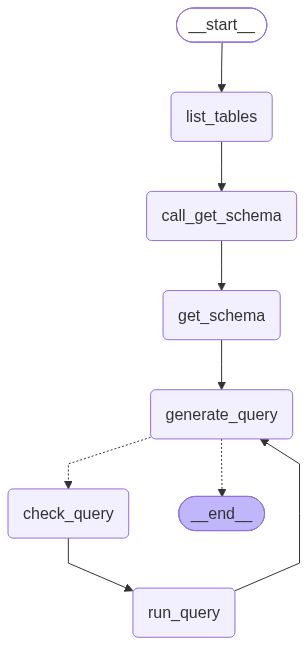

In [35]:
from IPython.display import Image, display

try:
    display(Image(graph_agent.get_graph().draw_mermaid_png()))
except Exception:
    print(graph_agent.get_graph().draw_mermaid())

In [45]:
stream = ask("Which genre on average has the longest tracks?", runnable=graph_agent)

Q: Which genre on average has the longest tracks?

Available tables: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track

To find out which genre has the longest tracks on average, we need to join the `Track` table with the `Genre` table via the `Genre` table's relationship with the `Track` table (assuming there's a foreign key relationship). Let's write a query to calculate the average track length for each genre and then find the genre with the highest average length.
It seems there was an error in the previous attempt to retrieve the schema. Let's try again by specifying the correct table names: `Track` and `Genre`.
It appears there was an issue with the previous attempt to retrieve the schema for the `Track` and `Genre` tables. Let's try calling the function again with the correct format.
It seems there is a persistent issue with the `sql_db_schema` tool. Let's proceed by directly formulating the SQL query based on the available

### Interrupt from inside the tool itself

In [46]:
from langchain_core.runnables import RunnableConfig
from langgraph.types import interrupt


@tool(
    run_query_tool.name,
    description=run_query_tool.description,
    args_schema=run_query_tool.args_schema,
)
def run_query_tool_with_interrupt(config: RunnableConfig, **tool_input):
    request = {
        "action": run_query_tool.name,
        "args": tool_input,
        "description": "Please review the tool call",
    }
    response = interrupt([request])

    if response["type"] == "accept":
        return run_query_tool.invoke(tool_input, config)
    if response["type"] == "edit":
        return run_query_tool.invoke(response["args"]["args"], config)
    if response["type"] == "response":
        return response["args"]
    raise ValueError(f"Unsupported interrupt response type: {response['type']}")


def should_run_query(state: MessagesState) -> Literal[END, "run_query"]:
    if not state["messages"][-1].tool_calls:
        return END
    return "run_query"


review_builder = StateGraph(MessagesState)
review_builder.add_node(list_tables)
review_builder.add_node(call_get_schema)
review_builder.add_node(get_schema_node, "get_schema")
review_builder.add_node(generate_query)
review_builder.add_node(ToolNode([run_query_tool_with_interrupt], name="run_query"), "run_query")

review_builder.add_edge(START, "list_tables")
review_builder.add_edge("list_tables", "call_get_schema")
review_builder.add_edge("call_get_schema", "get_schema")
review_builder.add_conditional_edges("get_schema", schema_ok)
review_builder.add_conditional_edges("generate_query", should_run_query)
review_builder.add_edge("run_query", "generate_query")

review_graph = review_builder.compile(checkpointer=checkpointer)
print("review graph ready")

review graph ready


In [47]:
import json

graph_config = {"configurable": {"thread_id": "graph-1"}}

stream = ask(
    "Which genre on average has the longest tracks?",
    runnable=review_graph,
    config=graph_config,
)

if stream.interrupted:
    for request in stream.interrupts[0].value:
        print(json.dumps(request, indent=2))

Q: Which genre on average has the longest tracks?

Available tables: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track




Let's retrieve the schema for the `Track` and `Genre` tables to understand their structure and how they are related.
The schema for the `Track` and `Genre` tables is as follows:

- **Track Table**
  - `TrackId`: INTEGER (Primary Key)
  - `Name`: NVARCHAR(200)
  - `AlbumId`: INTEGER
  - `MediaTypeId`: INTEGER (Foreign Key to `MediaType`)
  - `GenreId`: INTEGER (Foreign Key to `Genre`)
  - `Composer`: NVARCHAR(220)
  - `Milliseconds`: INTEGER
  - `Bytes`: INTEGER
  - `UnitPrice`: NUMERIC(10,2)

- **Genre Table**
  - `GenreId`: INTEGER (Primary Key)
  - `Name`: NVARCHAR(120)

To find the genre with the longest average track length, we need to join the `Track` and `Genre` tables on the `GenreId` column and calculate the average `Milliseconds` for each genre.

Let's write the SQL query to achieve this.

--- INTERRU

In [51]:
stream = stream_agent(review_graph, Command(resume={"type": "accept"}), graph_config)

The genre with the longest average track length is "Sci Fi & Fantasy" with an average length of approximately 2911783 milliseconds.

Here are the top 5 genres by average track length:
1. Sci Fi & Fantasy: 2911783 milliseconds
2. Science Fiction: 2625549 milliseconds
3. Drama: 2575284 milliseconds
4. TV Shows: 2145041 milliseconds
5. Comedy: 1585264 milliseconds

### Pull the traced runs back from LangSmith

In [53]:
if os.environ.get("LANGSMITH_TRACING") == "true":
    from langsmith import Client

    client = Client()
    runs = list(client.list_runs(project_name=LANGSMITH_PROJECT, is_root=True, limit=5))

    for run in runs:
        tokens = run.total_tokens or 0
        seconds = (run.end_time - run.start_time).total_seconds() if run.end_time else 0
        print(f"{run.name:<24}{tokens:>8} tokens{seconds:>8.1f}s  {run.status}")
        print(f"  {client.get_run_url(run=run)}")
else:
    print("tracing is off; set TRACING = True in the first cell and re-run")

C:\Users\joyjeetroy\AppData\Local\Temp\ipykernel_24188\2131564981.py:5: DeprecationWarning: list_runs() is deprecated and will be removed after Jan 31, 2027. Use client.runs.query() instead. See https://docs.langchain.com/langsmith/smithdb-sdk-migration#runs-query for the migration guide.
  runs = list(client.list_runs(project_name=LANGSMITH_PROJECT, is_root=True, limit=5))


LangGraph                   1951 tokens    58.1s  success


C:\Users\joyjeetroy\AppData\Local\Temp\ipykernel_24188\2131564981.py:11: DeprecationWarning: get_run_url() is deprecated and will be removed after Jan 31, 2027. Use client.runs.get_url() instead. See https://docs.langchain.com/langsmith/smithdb-sdk-migration#runs-get-url for the migration guide.
  print(f"  {client.get_run_url(run=run)}")


  https://smith.langchain.com/o/7a0d4b7e-e60b-4b10-96ed-daf28c5d5681/projects/p/299bfa31-5056-4fab-bb3b-f83aafc14025/r/01a0475c-e58a-73e2-9967-5d6a2977b44d?poll=true
LangGraph                   1853 tokens    69.9s  success
  https://smith.langchain.com/o/7a0d4b7e-e60b-4b10-96ed-daf28c5d5681/projects/p/299bfa31-5056-4fab-bb3b-f83aafc14025/r/01a0475b-bb03-72f0-854c-d923aace2284?poll=true
LangGraph                   3456 tokens   119.0s  success
  https://smith.langchain.com/o/7a0d4b7e-e60b-4b10-96ed-daf28c5d5681/projects/p/299bfa31-5056-4fab-bb3b-f83aafc14025/r/01a04759-d6ac-7bc3-8a03-0efd9de93133?poll=true
LangGraph                   2590 tokens   127.7s  success
  https://smith.langchain.com/o/7a0d4b7e-e60b-4b10-96ed-daf28c5d5681/projects/p/299bfa31-5056-4fab-bb3b-f83aafc14025/r/01a04757-a146-70a1-ace3-97c644f7c4c3?poll=true
LangGraph                   4349 tokens   214.3s  success
  https://smith.langchain.com/o/7a0d4b7e-e60b-4b10-96ed-daf28c5d5681/projects/p/299bfa31-5056-4fab-bb3b-

### Return a typed answer instead of prose

In [ ]:
from pydantic import BaseModel, Field


class SQLAnswer(BaseModel):
    answer: str = Field(description="Plain language answer to the question")
    sql: str = Field(description="The final SQL query that produced the answer")
    tables_used: list[str] = Field(description="Tables referenced by the final query")


QUESTION = "Which genre on average has the longest tracks?"

result = agent.invoke(user_turn(QUESTION))

transcript = []
for message in result["messages"]:
    for call in getattr(message, "tool_calls", []) or []:
        transcript.append(f"{call['name']} args: {call['args']}")
    if message.text:
        transcript.append(f"{type(message).__name__}: {message.text}")

joined = truncate("\n".join(transcript))
answer = model.with_structured_output(SQLAnswer).invoke(
    f"Question: {QUESTION}\n\nAgent transcript:\n{joined}\n\n"
    "Fill in the fields from this transcript. Answer in English."
)

print(answer.answer)
print(answer.sql)
print(answer.tables_used)

The genre with the longest average track length is 'Sci Fi & Fantasy', followed by 'Science Fiction', 'Drama', 'TV Shows', and 'Comedy'. The average length of tracks in the 'Sci Fi & Fantasy' genre is approximately 2,911,783 milliseconds (about 48.5 minutes).
SELECT g.Name, AVG(t.Milliseconds) AS AvgLength FROM Track t JOIN Genre g ON t.GenreId = g.GenreId GROUP BY g.Name ORDER BY AvgLength DESC LIMIT 5
['Track', 'Genre']


### Score the agent against a LangSmith dataset

In [67]:
DATASET = "sql-agent-chinook"

CASES = [
    ("Which genre on average has the longest tracks?", "Sci Fi & Fantasy"),
    ("Which country's customers have the highest total invoice amount?", "USA"),
    ("How many tracks are in the Rock genre?", "1297"),
]


def answered_correctly(outputs: dict, reference_outputs: dict) -> bool:
    messages = outputs.get("messages") or []
    text = messages[-1].text if messages else ""
    return reference_outputs["answer"].lower() in text.lower()


def checked_before_running(outputs: dict) -> bool:
    names = [
        call["name"]
        for message in outputs.get("messages") or []
        for call in getattr(message, "tool_calls", []) or []
    ]
    return "sql_db_query_checker" in names


def target(inputs: dict):
    return agent.invoke(user_turn(inputs["question"]))


if os.environ.get("LANGSMITH_TRACING") == "true":
    from langsmith import Client

    client = Client()

    if not client.has_dataset(dataset_name=DATASET):
        client.create_dataset(DATASET)
        client.create_examples(
            dataset_name=DATASET,
            examples=[
                {"inputs": {"question": question}, "outputs": {"answer": expected}}
                for question, expected in CASES
            ],
        )

    results = client.evaluate(
        target,
        data=DATASET,
        evaluators=[answered_correctly, checked_before_running],
        experiment_prefix="sql-agent",
        max_concurrency=1,
    )
    print(results)
else:
    print("tracing is off; set TRACING = True in the first cell and re-run")

c:\Users\joyjeetroy\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


View the evaluation results for experiment: 'sql-agent-7a7d6de1' at:
https://smith.langchain.com/o/7a0d4b7e-e60b-4b10-96ed-daf28c5d5681/datasets/a11844eb-6eb6-4fb3-91ab-45350b269444/compare?selectedSessions=2273baf3-c2c3-4991-9aed-ed1d04eab7a6




3it [07:56, 158.93s/it]

<ExperimentResults sql-agent-7a7d6de1>
